# ***Credit Wise Loan System Project***

# CreditWise Loan System

## Problem Statement

A mid-sized financial company named **SecureTrust Bank** offers **personal** and **home loans** to customers across urban and rural regions of India. Every day, hundreds of customers apply for loans through online and branch application systems.

Currently, the bank uses a **manual loan verification process**, where loan officers examine each application by checking income proofs, employment details, credit history, bank statements, and other supporting documents. This manual process is time-consuming, inconsistent, and prone to human error.

As a result, the bank faces two major challenges:

- Good customers are sometimes **rejected**, resulting in loss of business.
- High-risk customers are sometimes **approved**, leading to financial losses.

To overcome these challenges, the bank plans to develop an **Intelligent Loan Approval System** using **Machine Learning**. The system will automatically analyze customer information and predict whether a loan application should be **Approved** or **Rejected** before the final manual verification.

As a **Machine Learning Engineer**, your task is to design and develop this predictive system using historical customer loan data. The objective is to identify hidden patterns from previous loan records and provide accurate, fast, consistent, and unbiased loan approval decisions.

---

# Project Objective

The primary objective of this project is to build a Machine Learning model that predicts whether a customer's loan application should be approved or rejected based on applicant information.

The model should:

- Analyze customer details automatically.
- Reduce manual verification time.
- Improve loan approval accuracy.
- Minimize financial risk.
- Provide fast and consistent predictions.

---

# Dataset Description

Each row in the dataset represents **one loan applicant**.

The dataset contains multiple features describing the applicant's:

- Personal Information
- Financial Information
- Employment Details
- Credit History
- Loan Details

These features are used to train a Machine Learning model that predicts the final loan approval status.

---

# Target Variable

The target variable is:

**Loan Status**

Possible values:

- **Approved (1)**
- **Rejected (0)**

The goal of the model is to correctly predict the loan approval status for new applicants.

---

# Expected Outcome

After training the model, it should be able to:

- Predict whether a loan should be approved or rejected.
- Reduce processing time.
- Improve decision-making.
- Reduce human errors.
- Help the bank make faster and more reliable loan approval decisions.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.columns
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# ***1 Handle Missing Values***

In [5]:
# Separete Numerical and Categorical data

categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns

In [6]:
from sklearn.impute import SimpleImputer


num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [7]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [8]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [9]:
df["Employer_Category"]

0         Private
1         Private
2      Government
3      Government
4         Private
          ...    
995    Unemployed
996    Government
997           MNC
998       Private
999       Private
Name: Employer_Category, Length: 1000, dtype: object

# ***2 EDA***

### ***# How Balanced Our Classes?***

Text(0.5, 1.0, 'Loan Approved or Not?')

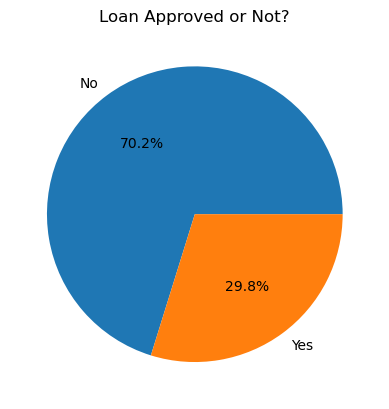

In [10]:
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Loan Approved or Not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

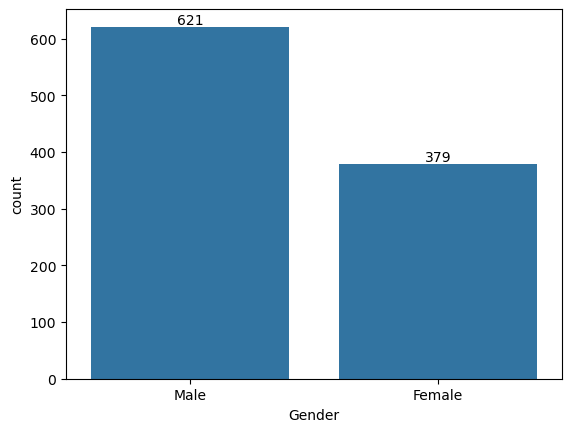

In [11]:
# Analyze categories
gendor_con=df["Gender"].value_counts()
ax=sns.barplot(gendor_con)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

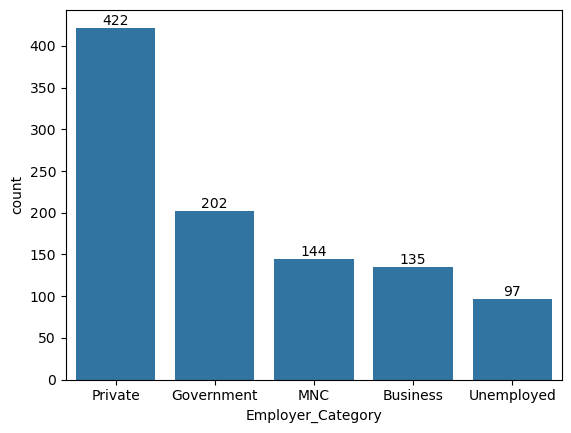

In [12]:
emp_count=df["Employer_Category"].value_counts()
ex=sns.barplot(emp_count)
ex.bar_label(ex.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

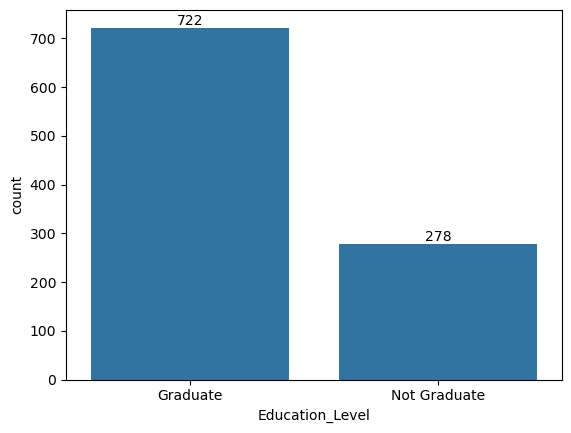

In [16]:
Education_count=df["Education_Level"].value_counts()
ex=sns.barplot(Education_count)
ex.bar_label(ex.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

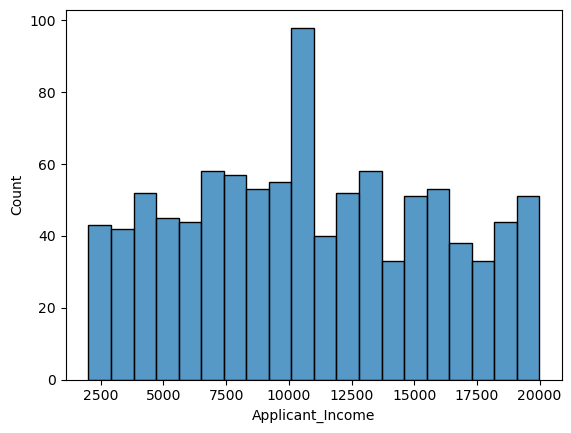

In [23]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

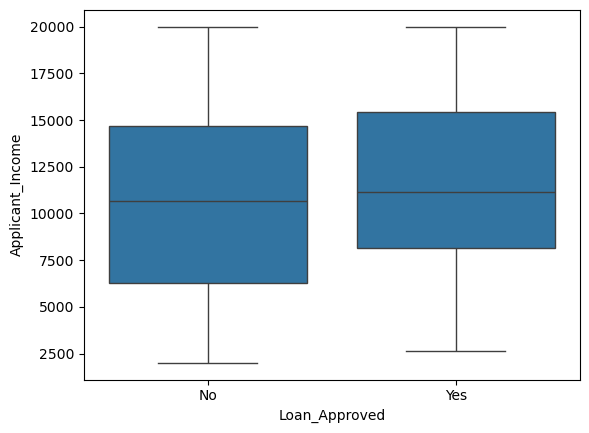

In [25]:
 # Outliers -Box Plt
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

In [26]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


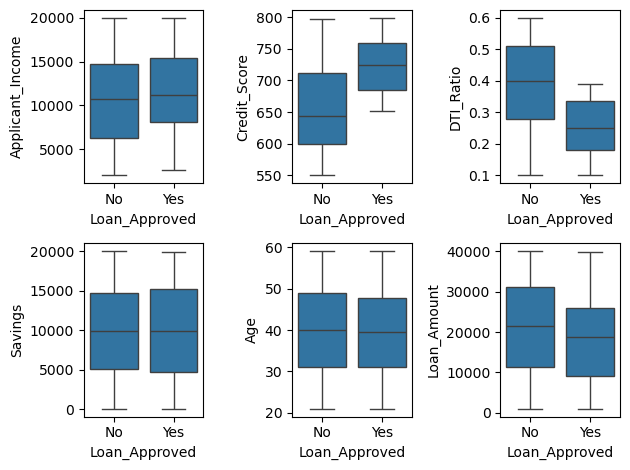

In [31]:
fig,axes=plt.subplots(2,3)
sns.boxplot(ax=axes[0,0] ,data=df,x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1] ,data=df,x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[0,2] ,data=df,x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,0] ,data=df,x="Loan_Approved", y="Savings")
sns.boxplot(ax=axes[1,1] ,data=df,x="Loan_Approved", y="Age")
sns.boxplot(ax=axes[1,2] ,data=df,x="Loan_Approved", y="Loan_Amount")
plt.tight_layout()


<Axes: xlabel='Credit_Score', ylabel='Count'>

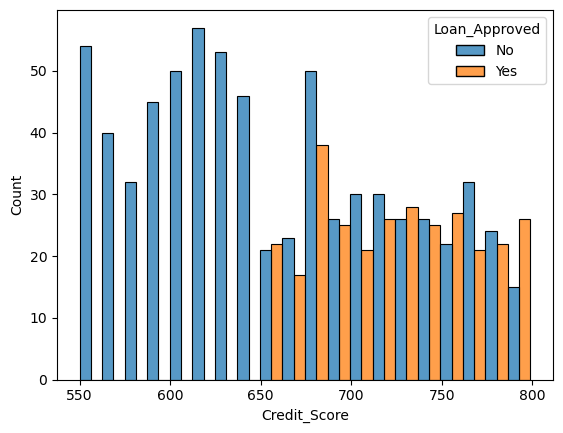

In [38]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [42]:
df=df.drop("Applicant_ID" , axis=1)

In [43]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding

Machine Learning models cannot directly understand **categorical (text)** data. Therefore, categorical values must be converted into numerical values. This process is called **Encoding**.

There are two commonly used encoding techniques:

- **Label Encoding**
- **One-Hot Encoding**

---

# 1. Label Encoding

**Label Encoding** assigns a unique integer to every category.

It is mainly used for **Ordinal Data**, where the categories have a natural order or ranking.

## Example

Suppose we have the Education Level feature:

| Education Level | Encoded Value |
|-----------------|--------------:|
| Undergraduate | 0 |
| Postgraduate | 1 |
| PhD | 2 |

Since the categories have an order,

\[
\text{Undergraduate} < \text{Postgraduate} < \text{PhD}
\]

Label Encoding is the correct choice.

Another example:

| Difficulty Level | Encoded Value |
|------------------|--------------:|
| Easy | 0 |
| Medium | 1 |
| Hard | 2 |

The numerical values preserve the natural ordering.

### Advantages

- Very simple.
- Requires only one column.
- Works well for Ordinal Data.

### Disadvantages

- Not suitable for Nominal Data.
- The model may incorrectly assume that larger numbers represent higher importance.

---

# 2. One-Hot Encoding

**One-Hot Encoding** creates a separate binary column for each category.

It is mainly used for **Nominal Data**, where there is **no natural order** among categories.

## Example

Suppose we have a Gender feature.

Original values:

| Gender |
|--------|
| Male |
| Female |
| Male |
| Female |

After One-Hot Encoding:

| Gender_Male | Gender_Female |
|-------------|---------------|
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 0 | 1 |

Each category gets its own binary (0 or 1) column.

Another example:

| Color |
|-------|
| Red |
| Blue |
| Green |

After One-Hot Encoding:

| Red | Blue | Green |
|----:|-----:|------:|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

Since there is **no order** between colors, One-Hot Encoding is the correct approach.

### Advantages

- Prevents the model from assuming any order.
- Ideal for Nominal Data.
- Improves model performance for many algorithms.

### Disadvantages

- Increases the number of columns.
- High-cardinality features can create many new columns.

---

# Label Encoding vs One-Hot Encoding

| Feature | Label Encoding | One-Hot Encoding |
|---------|----------------|------------------|
| Data Type | Ordinal | Nominal |
| Preserves Order | Yes | No |
| Number of Columns | One | Multiple |
| Risk of Misleading Order | Yes (for Nominal Data) | No |
| Memory Usage | Low | Higher |

---

# When to Use Which?

### Use **Label Encoding** when:

- Data is **Ordinal**.
- Categories have a meaningful order.

Examples:

- Education Level
- Satisfaction Level
- Difficulty Level
- Experience Level

---

### Use **One-Hot Encoding** when:

- Data is **Nominal**.
- Categories have **no natural order**.

Examples:

- Gender
- City
- Country
- Blood Group
- Department
- Color

---

# Summary

- **Encoding** converts categorical data into numerical form.
- **Label Encoding** is suitable for **Ordinal Data** because it preserves the order of categories.
- **One-Hot Encoding** is suitable for **Nominal Data** because it creates separate binary columns and does not introduce any artificial ordering.
- Choosing the correct encoding technique is important because it directly affects the performance and accuracy of Machine Learning models.

In [45]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [46]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [47]:
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [48]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [49]:
cols = [
    "Employment_Status",
    "Marital_Status",
    "Loan_Purpose",
    "Property_Area",
    "Gender",
    "Employer_Category"
]

ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

df = pd.concat(
    [df.drop(columns=cols), encoded_df],
    axis=1
)

In [50]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        